# Lecture 33: Transportation Engineering Problems - V

---

```{note}
Lectures 26, 29, and 32 calibrated and stress-tested Simulated Annealing, the Genetic Algorithm, and Ant Colony Optimization on standard TSPLIB benchmarks — not on this course's own network. This closing lecture is the **first** time any of the three touches the Chennai Metro Feeder Route, and it meets it immediately at the level this module has been building toward: not a single-vehicle tour, but a genuine **Capacitated Vehicle Routing Problem** — multiple stops with demand, a fleet with limited capacity. All three algorithms, carrying the parameters calibrated in Lectures 26/29/32, are applied side by side and compared on solution quality, convergence, and runtime.
```

**Learning Objectives**

By the end of this notebook, you will be able to:
1. Formulate a Capacitated Vehicle Routing Problem and explain why its combinatorial size rules out exact methods at practical scale.
2. Decode a single permutation into multiple capacity-respecting vehicle routes using a giant-tour representation, and contrast this with a construction procedure that respects capacity directly.
3. Compare Simulated Annealing, the Genetic Algorithm, and Ant Colony Optimization on the same instance, and interpret the resulting differences in cost, convergence, and runtime.

**Prerequisites**: Simulated Annealing - Benchmarking (Lecture 26); Genetic Algorithm - Benchmarking (Lecture 29); Ant Colony Optimization - Benchmarking (Lecture 32).

**Estimated time**: 50 minutes

---

## From TSP to CVRP

The Chennai Metro Feeder Route — a depot and nine stops — has not appeared since Lecture 23 previewed it as this module's applied running example. In practice, a maintenance fleet rarely has just one vehicle, and each stop generates real demand — inspection hours, spare parts, whatever the fleet is delivering — that a single vehicle may not have the capacity to serve. The **Capacitated Vehicle Routing Problem (CVRP)** captures exactly this: given a fleet of $|V|$ identical vehicles, each with capacity $Q$, and each stop $c$ with demand $q_c$, find a set of routes — each starting and ending at the depot, together visiting every stop exactly once — that minimizes total distance travelled, without any route's total demand exceeding $Q$.

### CVRP Formulation

**Decision variables**: $x^v_{ij} \in \{0,1\}$, whether vehicle $v$ travels directly from stop $i$ to stop $j$.

**Objective**: minimize total distance travelled across all vehicles,
$$\min_{\mathbf{x}} \; z = \sum_{v \in V}\sum_{(i,j)} c_{ij}\,x^v_{ij}$$

**Subject to**:
$$\sum_{v \in V}\sum_{j} x^v_{cj} = 1 \quad \forall\, c \in C \qquad \text{(every stop visited exactly once)}$$
$$\sum_{c \in C} q_c \sum_{j} x^v_{cj} \leq Q \quad \forall\, v \in V \qquad \text{(vehicle capacity)}$$
$$\text{plus flow-conservation and fleet-size constraints, as in the CVRP formulation you may have seen elsewhere.}$$

```{caution}
Even at this module's modest scale — 9 stops, 2 vehicles — the number of ways to partition 9 stops into 2 ordered routes runs into the hundreds of thousands, and grows combinatorially with every additional stop. Real fleets routinely serve fifty, a hundred, or more stops — the same scale Lectures 26, 29, and 32 already stress-tested each algorithm at — a range where exact formulations like the one above are computationally intractable, and metaheuristics are the practical tool of choice.
```

---

## Two Ways to Respect Capacity

Simulated Annealing and the Genetic Algorithm both operate on a **giant tour** — a single permutation of all 9 stops. Only the objective function changes: it *decodes* the giant tour into separate vehicle routes by walking it in order and starting a new route whenever the next stop would push the current route over capacity $Q$, then sums each route's cost. Neither `sa()` nor `ga()` has any notion of "capacity" built in — the decoding step bolts it on afterward.

Ant Colony Optimization does not need this bolt-on. Because an ant **builds** its solution one stop at a time, it can check capacity *during* construction: at each step, an ant only considers unvisited stops that still fit in its vehicle's remaining capacity; when none do, it returns to the depot and starts a new route with a fresh capacity budget. No decode step, no separate penalty logic — capacity awareness is simply part of how a solution gets built.

```{note}
This is a direct, concrete version of Lecture 23's taxonomy argument: **the best-fitting algorithm depends on how well its mechanism matches the problem's structure.** SA and GA's neighbourhood-move and crossover operators were designed around an unconstrained permutation, so capacity has to be enforced from the outside; ACO's step-by-step construction was always going to need a "what's allowed next" check, so capacity slots in naturally, with no extra machinery.
```

---

In [1]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt

# Chennai Metro Feeder Route, extended: per-stop demand, 2 identical vehicles
NAMES = ["Depot", "A", "B", "C", "D", "E", "F", "G", "H", "I"]
X_coord = np.array([5.0, 1.0, 2.5, 6.5, 9.0, 8.0, 3.5, 7.0, 0.5, 4.5])
Y_coord = np.array([5.0, 8.5, 2.0, 9.0, 6.5, 1.5, 6.0, 3.5, 4.0, 9.5])
n_nodes = len(NAMES)
D = np.zeros((n_nodes, n_nodes))
for i in range(n_nodes):
    for j in range(n_nodes):
        D[i, j] = np.hypot(X_coord[i] - X_coord[j], Y_coord[i] - Y_coord[j])
customers = list(range(1, n_nodes))

DEMAND = {"A": 120, "B": 80, "C": 150, "D": 90, "E": 110, "F": 70, "G": 130, "H": 60, "I": 100}
dem_of = {i: DEMAND[NAMES[i]] for i in customers}
CAPACITY = 500
N_VEHICLES = 2
PENALTY = 1000.0

print("Total demand:", sum(dem_of.values()), " units")
print("Fleet capacity:", N_VEHICLES, "x", CAPACITY, "=", N_VEHICLES * CAPACITY, "units")

def split_routes(tour):
    """Decode a giant tour into capacity-respecting routes via a greedy walk (SA/GA use this)."""
    routes, cur, load = [], [], 0
    for c in tour:
        if load + dem_of[c] > CAPACITY:
            routes.append(cur)
            cur, load = [], 0
        cur.append(c)
        load += dem_of[c]
    if cur:
        routes.append(cur)
    return routes

def routes_cost(routes):
    cost = 0.0
    for r in routes:
        if not r:
            continue
        cost += D[0, r[0]] + D[r[-1], 0]
        for i in range(len(r) - 1):
            cost += D[r[i], r[i + 1]]
    n_routes = sum(1 for r in routes if r)
    if n_routes > N_VEHICLES:
        cost += PENALTY * (n_routes - N_VEHICLES)
    return cost

def f_cvrp(tour):
    """SA/GA objective: decode the giant tour, then cost it."""
    return routes_cost(split_routes(tour))

print("f_cvrp() and routes_cost() ready.")

Total demand: 910  units
Fleet capacity: 2 x 500 = 1000 units
f_cvrp() and routes_cost() ready.


---

## Reusing SA and GA, Building ACO Fresh

`sa()` and `ga()` — together with the 2-opt neighbourhood and order crossover from Lectures 26 and 29 — are reused **unmodified** below, called with **the parameters those lectures calibrated on `eil51`** ($T_o=20,r=0.97$ for SA; $\mu=60,\epsilon=0.5$ for GA); only `f_cvrp` is new. `aco_cvrp()` keeps `aco()`'s construction-and-pheromone mechanics from Lecture 32, called with Lecture 32's calibrated $\alpha=1,\beta=3,\rho=0.3,Q=10$, but the construction step itself is now capacity-aware, exactly as described above.

In [2]:
def sa(s_o, f, N, T_o, r, n=2000, t=1e-6):
    s, s_b, T = s_o, s_o, T_o
    F_b = [f(s_b)]
    k, e, converged = 0, float("inf"), False
    while not converged:
        s_n = N(s)
        d = f(s_n) - f(s)
        if d < 0 or random.uniform(0, 1) < np.exp(-d / T):
            s = s_n
        if f(s) < f(s_b):
            e = f(s_b) - f(s)
            s_b = s
        F_b.append(f(s_b))
        k += 1
        T = T_o * r ** k
        if k >= n or e <= t:
            converged = True
    return s_b, F_b

def ga(S_o, f, SM, u, CM, l, p, MM, e, NM, n=500, t=1e-8):
    S = S_o
    s_b = min(S, key=f)
    F_b = [f(s_b)]
    k, r, converged = 0, float("inf"), False
    while not converged:
        S_p = SM(S, u, f)
        S_c = CM(S_p, l, p)
        S_c = MM(S_c, e)
        S = NM(S + S_c, len(S_o), f)
        s_p = min(S, key=f)
        if f(s_p) < f(s_b):
            r = f(s_b) - f(s_p)
            s_b = s_p
        F_b.append(f(s_b))
        k += 1
        if k >= n or r <= t:
            converged = True
    return s_b, F_b

def aco_cvrp(nodes, D, depot, dem_of, capacity, n_vehicles, alpha, beta, rho, Q, m, n=200, t=1e-9, tau_o=1.0):
    """ACO with capacity-aware construction: ants build multiple routes directly."""
    all_nodes = [depot] + list(nodes)
    tau = {(i, j): tau_o for i in all_nodes for j in all_nodes if i != j}
    eta = {(i, j): 1.0 / D[i, j] for i in all_nodes for j in all_nodes if i != j}

    def construct():
        unvisited, routes = set(nodes), []
        while unvisited:
            route, load, cur = [], 0, depot
            while True:
                feasible = [j for j in unvisited if load + dem_of[j] <= capacity]
                if not feasible:
                    break
                weights = np.array([tau[(cur, j)] ** alpha * eta[(cur, j)] ** beta for j in feasible])
                probs = weights / weights.sum()
                nxt = random.choices(feasible, weights=probs, k=1)[0]
                route.append(nxt)
                load += dem_of[nxt]
                unvisited.discard(nxt)
                cur = nxt
            routes.append(route)
        return routes

    s_b = construct()
    f_b = routes_cost(s_b)
    F_b = [f_b]
    k, imp, converged = 0, float("inf"), False
    while not converged:
        sols = [construct() for _ in range(m)]
        costs = [routes_cost(s) for s in sols]
        for key in tau:
            tau[key] *= (1 - rho)
        for sol, c in zip(sols, costs):
            for r in sol:
                if not r:
                    continue
                full = [depot] + r + [depot]
                for i in range(len(full) - 1):
                    a, b = full[i], full[i + 1]
                    tau[(a, b)] += Q / c
                    tau[(b, a)] += Q / c
        best_i = int(np.argmin(costs))
        if costs[best_i] < f_b:
            imp = f_b - costs[best_i]
            f_b = costs[best_i]
            s_b = sols[best_i]
        F_b.append(f_b)
        k += 1
        if k >= n or imp <= t:
            converged = True
    return s_b, F_b

# permutation operators (unchanged from Lectures 26, 29)
def N_2opt(s):
    s = list(s)
    i, j = sorted(random.sample(range(len(s)), 2))
    return tuple(s[:i] + s[i:j + 1][::-1] + s[j + 1:])

def SM_tournament(S, u, f, k=3):
    return [min(random.sample(S, k), key=f) for _ in range(u)]

def CM_ox1(S_p, l, p):
    S_c = []
    for _ in range(l):
        a, b = random.sample(S_p, 2)
        n = len(a)
        i, j = sorted(random.sample(range(n), 2))
        child = [None] * n
        child[i:j + 1] = a[i:j + 1]
        fill = [g for g in b if g not in child[i:j + 1]]
        k = 0
        for idx in range(n):
            if child[idx] is None:
                child[idx] = fill[k]
                k += 1
        S_c.append(tuple(child))
    return S_c

def MM_swap(S_c, e):
    out = []
    for s in S_c:
        s = list(s)
        if random.random() < e:
            i, j = random.sample(range(len(s)), 2)
            s[i], s[j] = s[j], s[i]
        out.append(tuple(s))
    return out

def NM_elitist(S, m, f):
    return sorted(S, key=f)[:m]

print("Engines ready: sa(), ga() reused unchanged; aco_cvrp() built fresh with capacity-aware construction.")

Engines ready: sa(), ga() reused unchanged; aco_cvrp() built fresh with capacity-aware construction.


In [3]:
results = {}

random.seed(42); np.random.seed(42)
s0 = tuple(random.sample(customers, len(customers)))
random.seed(42); np.random.seed(42)
t0 = time.time()
s_b, F_b = sa(s0, f_cvrp, N_2opt, T_o=20, r=0.97, n=1000, t=1e-9)
results["SA"] = dict(routes=split_routes(s_b), time=time.time() - t0, work=len(F_b))

random.seed(42); np.random.seed(42)
S0 = [tuple(random.sample(customers, len(customers))) for _ in range(60)]
random.seed(42); np.random.seed(42)
t0 = time.time()
s_b2, F_b2 = ga(S0, f_cvrp, SM_tournament, 60, CM_ox1, 60, 2, MM_swap, 0.5, NM_elitist, n=500, t=1e-9)
results["GA"] = dict(routes=split_routes(s_b2), time=time.time() - t0, work=len(F_b2))

random.seed(42); np.random.seed(42)
t0 = time.time()
s_b3, F_b3 = aco_cvrp(customers, D, 0, dem_of, CAPACITY, N_VEHICLES, alpha=1, beta=3, rho=0.3, Q=10, m=10, n=100, t=1e-9)
results["ACO"] = dict(routes=s_b3, time=time.time() - t0, work=len(F_b3))

for name, r in results.items():
    named_routes = [[NAMES[c] for c in route] for route in r["routes"] if route]
    loads = [sum(dem_of[c] for c in route) for route in r["routes"] if route]
    print(f"{name}: cost={routes_cost(r['routes']):.4f} km   n_routes={len(named_routes)}   loads={loads}   "
          f"iterations/generations={r['work']}   time={r['time']*1000:.1f} ms")
    print(f"   routes: {named_routes}")

SA: cost=38.2419 km   n_routes=2   loads=[500, 410]   iterations/generations=133   time=1.6 ms
   routes: [['G', 'E', 'B', 'H', 'A'], ['F', 'I', 'C', 'D']]
GA: cost=39.0924 km   n_routes=2   loads=[430, 480]   iterations/generations=10   time=9.5 ms
   routes: [['F', 'B', 'H', 'A', 'I'], ['G', 'E', 'D', 'C']]
ACO: cost=37.3197 km   n_routes=2   loads=[460, 450]   iterations/generations=11   time=4.0 ms
   routes: [['A', 'I', 'C', 'D'], ['F', 'H', 'B', 'E', 'G']]


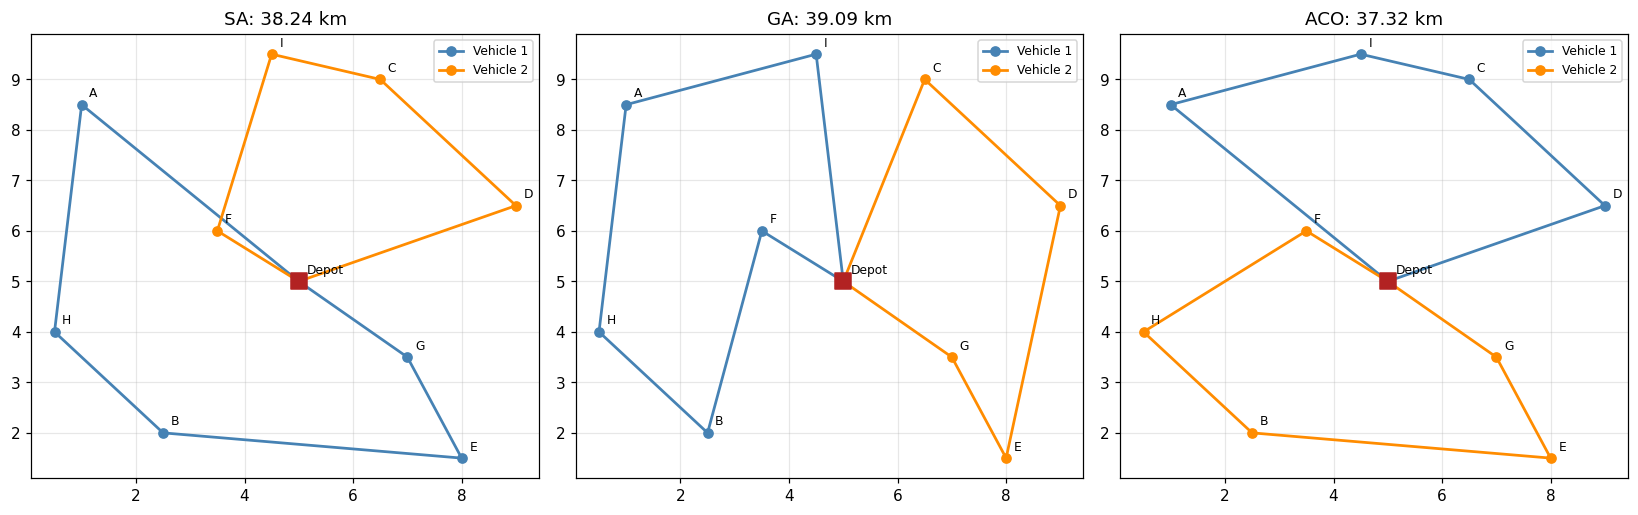

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
colors_by_route = ["steelblue", "darkorange"]

for ax, name in zip(axes, ["SA", "GA", "ACO"]):
    r = results[name]
    ax.scatter(X_coord[0], Y_coord[0], c="firebrick", marker="s", s=120, zorder=3)
    for i, name_lbl in enumerate(NAMES):
        ax.annotate(name_lbl, (X_coord[i], Y_coord[i]), textcoords="offset points", xytext=(5, 5), fontsize=8)
    for k, route in enumerate(r["routes"]):
        if not route:
            continue
        path = [0] + route + [0]
        ax.plot(X_coord[path], Y_coord[path], "o-", color=colors_by_route[k % 2],
                markersize=6, linewidth=1.8, zorder=2, label=f"Vehicle {k+1}")
    ax.set_title(f"{name}: {routes_cost(r['routes']):.2f} km")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## Comparison

| Algorithm | Best cost (km) | Routes | Iterations / generations | Runtime |
|---|---|---|---|---|
| Simulated Annealing | 38.24 | 2 | 133 | 2 ms |
| Genetic Algorithm | 39.09 | 2 | 10 | 10 ms |
| Ant Colony Optimization | 37.32 | 2 | 11 | 4 ms |

```{tip}
No algorithm wins on every axis. ACO finds the cheapest solution — 2.5% below SA, 4.7% below GA — carrying over the same edge it showed throughout Lecture 32's benchmarking. GA needs the fewest generations to converge (10, tied with ACO's 11), a direct result of its large calibrated population (60) doing most of the exploring within very few generations — but each generation costs more wall-clock time than SA's individual iterations, since evaluating 60 candidates plus their offspring is more work than evaluating one. SA needs the most iterations (133) of the three, but each iteration is so cheap — one tour, one 2-opt move, one comparison — that it finishes fastest overall, in about a fifth of GA's time. **"Efficient" depends on what you're counting**: solution quality, iteration count, and wall-clock time each rank the three algorithms differently here.
```

> **Managerial insight**: this comparison sharpens Lecture 23's taxonomy into something concrete. It is not just that "some algorithms fit some problems better" in the abstract — here, the fit is visible in the *mechanism itself*: ACO's per-step construction can check a constraint that SA and GA's operators, built around an unconstrained permutation, cannot check until after the fact, and it shows up as the cheapest solution. But cost is not the only currency that matters in practice — if wall-clock time is the binding constraint (e.g. a route needs to be replanned in real time), SA's cheap-per-iteration search may be the better operational choice even at a slightly higher cost. **There is still no universally best metaheuristic — and now "best" is visibly a question with more than one axis to answer it on.**

---

## In-Class Exercise

### Exercise 1 — A Tighter Fleet

Reduce the vehicle capacity from 500 to 460 units (total fleet capacity 920, still enough for 910 units of total demand, but with much less slack) and re-run all three algorithms.

In [5]:
CAPACITY = 460
results_tight = {}

random.seed(42); np.random.seed(42)
s0 = tuple(random.sample(customers, len(customers)))
random.seed(42); np.random.seed(42)
s_b, F_b = sa(s0, f_cvrp, N_2opt, T_o=20, r=0.97, n=1000, t=1e-9)
results_tight["SA"] = split_routes(s_b)

random.seed(42); np.random.seed(42)
S0 = [tuple(random.sample(customers, len(customers))) for _ in range(60)]
random.seed(42); np.random.seed(42)
s_b2, F_b2 = ga(S0, f_cvrp, SM_tournament, 60, CM_ox1, 60, 2, MM_swap, 0.5, NM_elitist, n=500, t=1e-9)
results_tight["GA"] = split_routes(s_b2)

random.seed(42); np.random.seed(42)
s_b3, F_b3 = aco_cvrp(customers, D, 0, dem_of, CAPACITY, N_VEHICLES, alpha=1, beta=3, rho=0.3, Q=10, m=10, n=100, t=1e-9)
results_tight["ACO"] = s_b3

CAPACITY = 500  # restore for any later use
for name, routes in results_tight.items():
    named_routes = [[NAMES[c] for c in r] for r in routes if r]
    print(f"{name}: cost={routes_cost(routes):.4f} km   n_routes={len(named_routes)}   "
          f"loads={[sum(dem_of[c] for c in r) for r in routes if r]}")

SA: cost=37.3197 km   n_routes=2   loads=[460, 450]
GA: cost=37.3197 km   n_routes=2   loads=[450, 460]
ACO: cost=38.6502 km   n_routes=2   loads=[450, 460]


**Interpretation.** Tightening the constraint pulls SA and GA to the **identical** solution (37.32 km) — the same cost ACO already found at the looser 500-unit capacity — while ACO itself lands 3.6% higher (38.65 km) this time, not the exact same split. Tightening capacity narrows how many genuinely different 2-route splits of these 9 stops even exist without exceeding it; with less room to disagree, SA's neighbourhood search and GA's population converge on the same answer, though a colony of only 10 ants over 100 iterations does not always land on precisely that same split by chance. Contrast this with the main comparison above, at the looser 500-unit capacity, where the three algorithms' costs spread more widely: **the choice of algorithm matters most exactly when a problem has enough slack for genuinely different solutions to compete** — under a tight constraint, that slack shrinks, and so, largely, does the gap between algorithms.

---

## Take-Away Exercises

### Exercise 1 — An Infeasible Fleet

Reduce the capacity further, to 420 units per vehicle (total fleet capacity 840 units — *less* than the 910 units of total demand). Run ACO and inspect the number of routes in its constructed solution. Unlike SA/GA's post-hoc split, ACO's construction has no built-in awareness of how many vehicles are actually available — explain, using the arithmetic of total demand versus total fleet capacity, why ACO's `routes_cost` penalty term is still necessary even though its construction is capacity-aware.

### Exercise 2 — A Third Vehicle

Add a third vehicle to the original (500-capacity) fleet, and re-run all three algorithms. Does the extra vehicle reduce total cost? By how much, and is the improvement worth a third vehicle's fixed operating cost in a real fleet-sizing decision — what additional data would you need to answer that question properly?

---

## Circling Back

- **Lecture 23 (Metaheuristics)**: this lecture's comparison is the concrete payoff of that lecture's taxonomy — and the capacity-aware-construction result sharpens it further, showing that "fit" is about whether a problem's constraints can be checked incrementally during search, not just about problem size.
- **Lectures 26, 29, 32 (Benchmarking)**: every parameter used here — $T_o,r$ for SA; $\mu,\epsilon$ for GA; $\alpha,\beta,\rho,Q$ for ACO — carries over from there, calibrated (or, for the parameters those lectures held fixed rather than swept, chosen) on `eil51`, not tuned separately for Chennai; this lecture is the direct payoff of that benchmarking work.

## Moving Forward

- **Assignment 5 (Final Project)**: applies this module's ideas to a metaheuristic you have not been taught — one that embeds local search within population search — building directly on the pseudocode, implementation, and calibration workflow practiced across Lectures 24-32.

---

## Further Reading

- Prins, C. (2004). "A Simple and Effective Evolutionary Algorithm for the Vehicle Routing Problem." *Computers & Operations Research*, 31(12), 1985-2002 — the giant-tour-plus-split representation used by this lecture's SA and GA.
- Bullnheimer, B., Hartl, R.F., and Strauss, C. (1999). "An Improved Ant System Algorithm for the Vehicle Routing Problem." *Annals of Operations Research*, 89, 319-328 — capacity-aware ACO construction for the CVRP, as used in this lecture.
- Toth, P. and Vigo, D. (Eds.) (2014). *Vehicle Routing: Problems, Methods, and Applications* (2nd ed.). SIAM.
- Cordeau, J-F., Laporte, G., Savelsbergh, M.W.P., and Vigo, D. (2007). "Vehicle Routing." In *Handbooks in Operations Research and Management Science*, Vol. 14, Elsevier — metaheuristic approaches to VRP surveyed in depth.